In [1]:
import torch
import torch_geometric as pyg
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch_sparse import SparseTensor
from torch.utils.data import DataLoader, SubsetRandomSampler

from common.utils import Utils
from common.nn_params import NNParams
from common.feed_fwd_nn import FeedFwdNN
from common.graph_conv_nn import GraphConvNN
from common.graph_sage_nn import GraphSageNN
from common.nn_model import NNModel, NNTrainParams
from common.graph_att_nn import GraphAttNN, GraphAttNNParams

In [2]:
dataset = pyg.datasets.Reddit2(
    root="./data"
    , transform=pyg.transforms.Compose(
        [
            pyg.transforms.NormalizeFeatures()
            , pyg.transforms.ToSparseTensor()
        ]
    )
)

In [3]:
N_NEIGHBORS = [20, 15, 10]

train_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=True
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.train_mask
    , batch_size=int(dataset._data.train_mask.sum())
)

val_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=False
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.val_mask
    , batch_size=int(dataset._data.val_mask.sum())
)

print(len(val_loader.dataset))
print(len(train_loader.dataset))

/opt/conda/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:50: UserWarning: Using '{self.__class__.__name__}' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn("Using '{self.__class__.__name__}' without a "


23699
153932


In [4]:
n_heads = 4
n_epochs = 1000
optims = ["adam"]
lrs = [1e-2]
weight_decay = 5e-4

dropout_probs = [0.25]
hidden_dimss = [
    [128]
]

paramss = [
    NNParams(
        hidden_dims=hidden_dims
        , dropout_prob=dropout_prob
        , input_dim=dataset.num_features
        , output_dim=dataset.num_classes
    )
        for dropout_prob in dropout_probs
        for hidden_dims in hidden_dimss
]

nets = []
nets += [
    GraphAttNN(params=params) for params in [
        GraphAttNNParams(
            n_heads=n_heads
            , input_dim=params.input_dim
            , output_dim=params.output_dim
            , hidden_dims=params.hidden_dims
            , dropout_prob=params.dropout_prob
        )   for params in paramss
    ]
]

# nets += [GraphSageNN(params=params) for params in paramss]
# nets += [GraphConvNN(params=params) for params in paramss]
# nets += [FeedFwdNN(params=params) for params in paramss]

models = [NNModel(device="cpu", net=net) for net in nets]

train_params = [
    train_param
        for train_param in [
            NNTrainParams(
                optim=optim
                , learning_rate=lr
                , n_epochs=n_epochs
                , val_loader=val_loader
                , train_loader=train_loader
                , weight_decay=weight_decay
            )
                for lr in lrs
                for optim in optims 
        ]
]

In [5]:
trains = {
    train_str: (model, train_idps)
        for model, (train_str, train_idps) in [
            (model, model.train(params=train_param))
                for model in models
                for train_param in train_params
        ]
}

GraphAttNN={dims=[602, 128, 41], dropout=0.25, heads=4} x Train=[epochs=1000, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 1000/1000 [10:25:12<00:00, 37.51s/it, error: 0.2491]  


In [6]:
top_model_names = [
    kvp[0] for kvp in sorted(
        list(trains.items())
        , key=lambda kvp: min(
            kvp[1][1]
            , key=lambda idp: idp.val_error
        ).val_error
    )[:10]
]

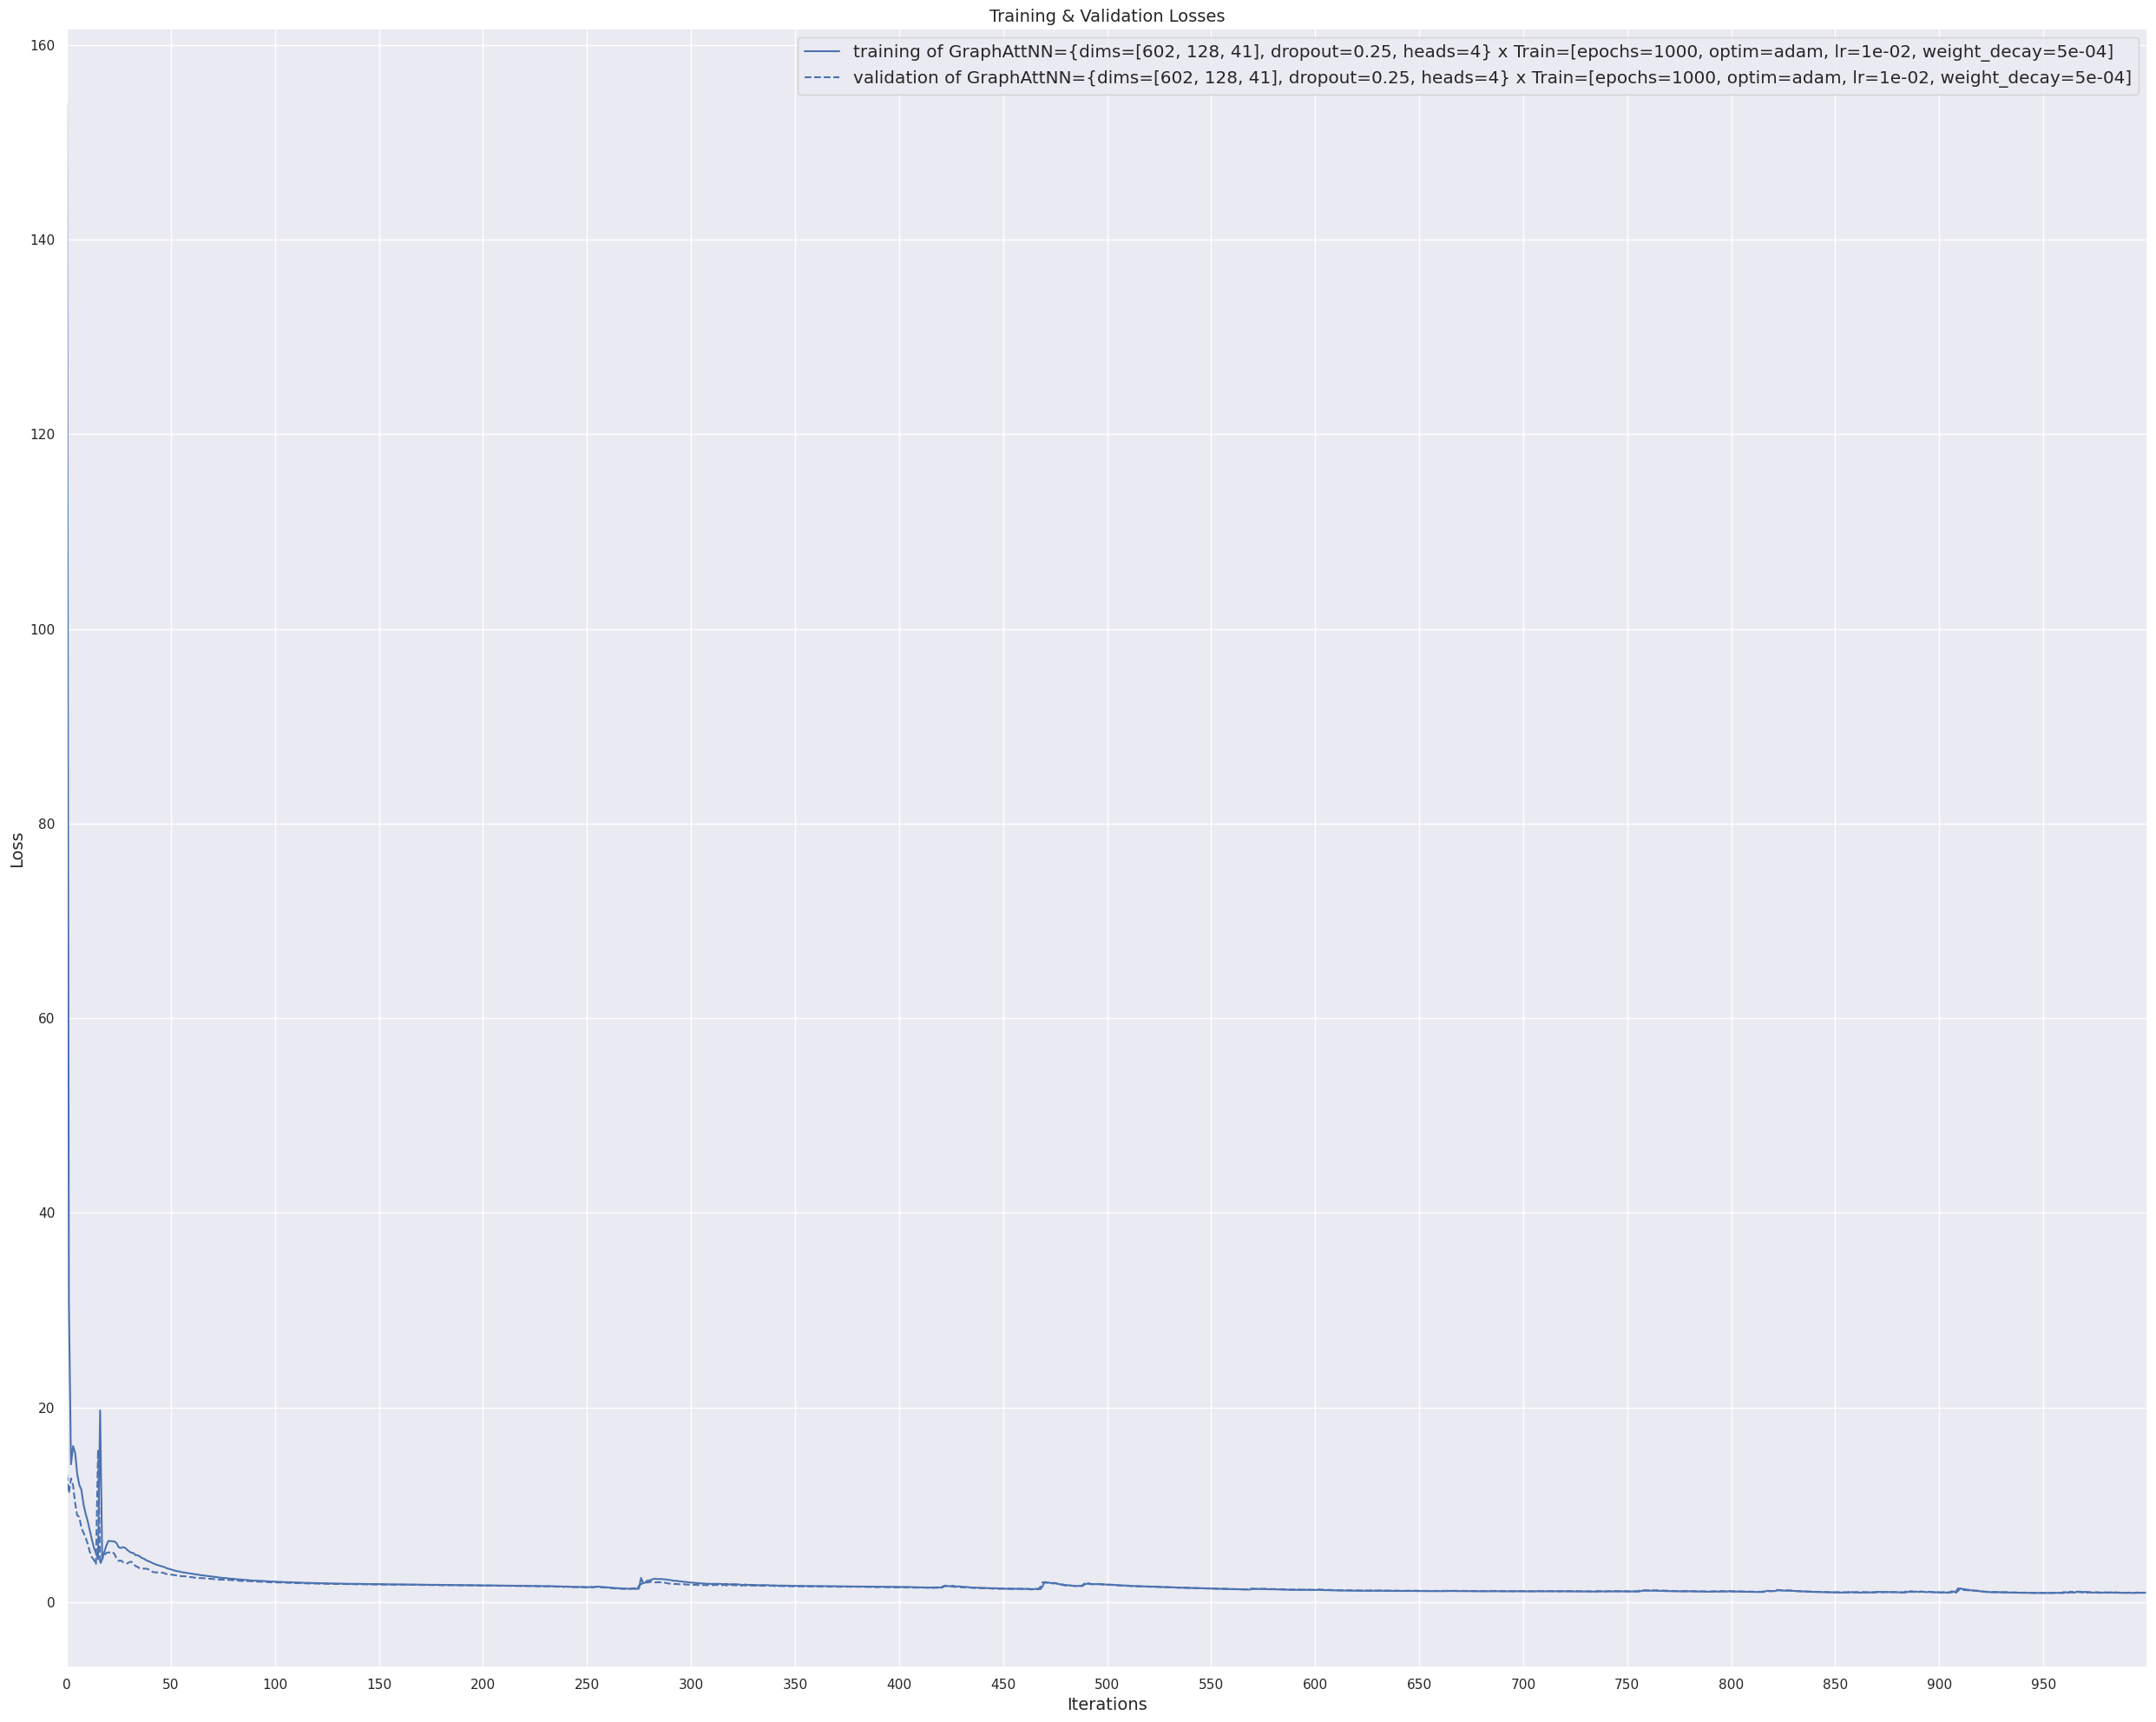

In [14]:
Utils.multi_line_plot(
    x_ticks_inc=50
    , fig_size=(25, 20)
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Losses"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_loss for model_idp in trains[model_name][1]], [model_idp.val_loss for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

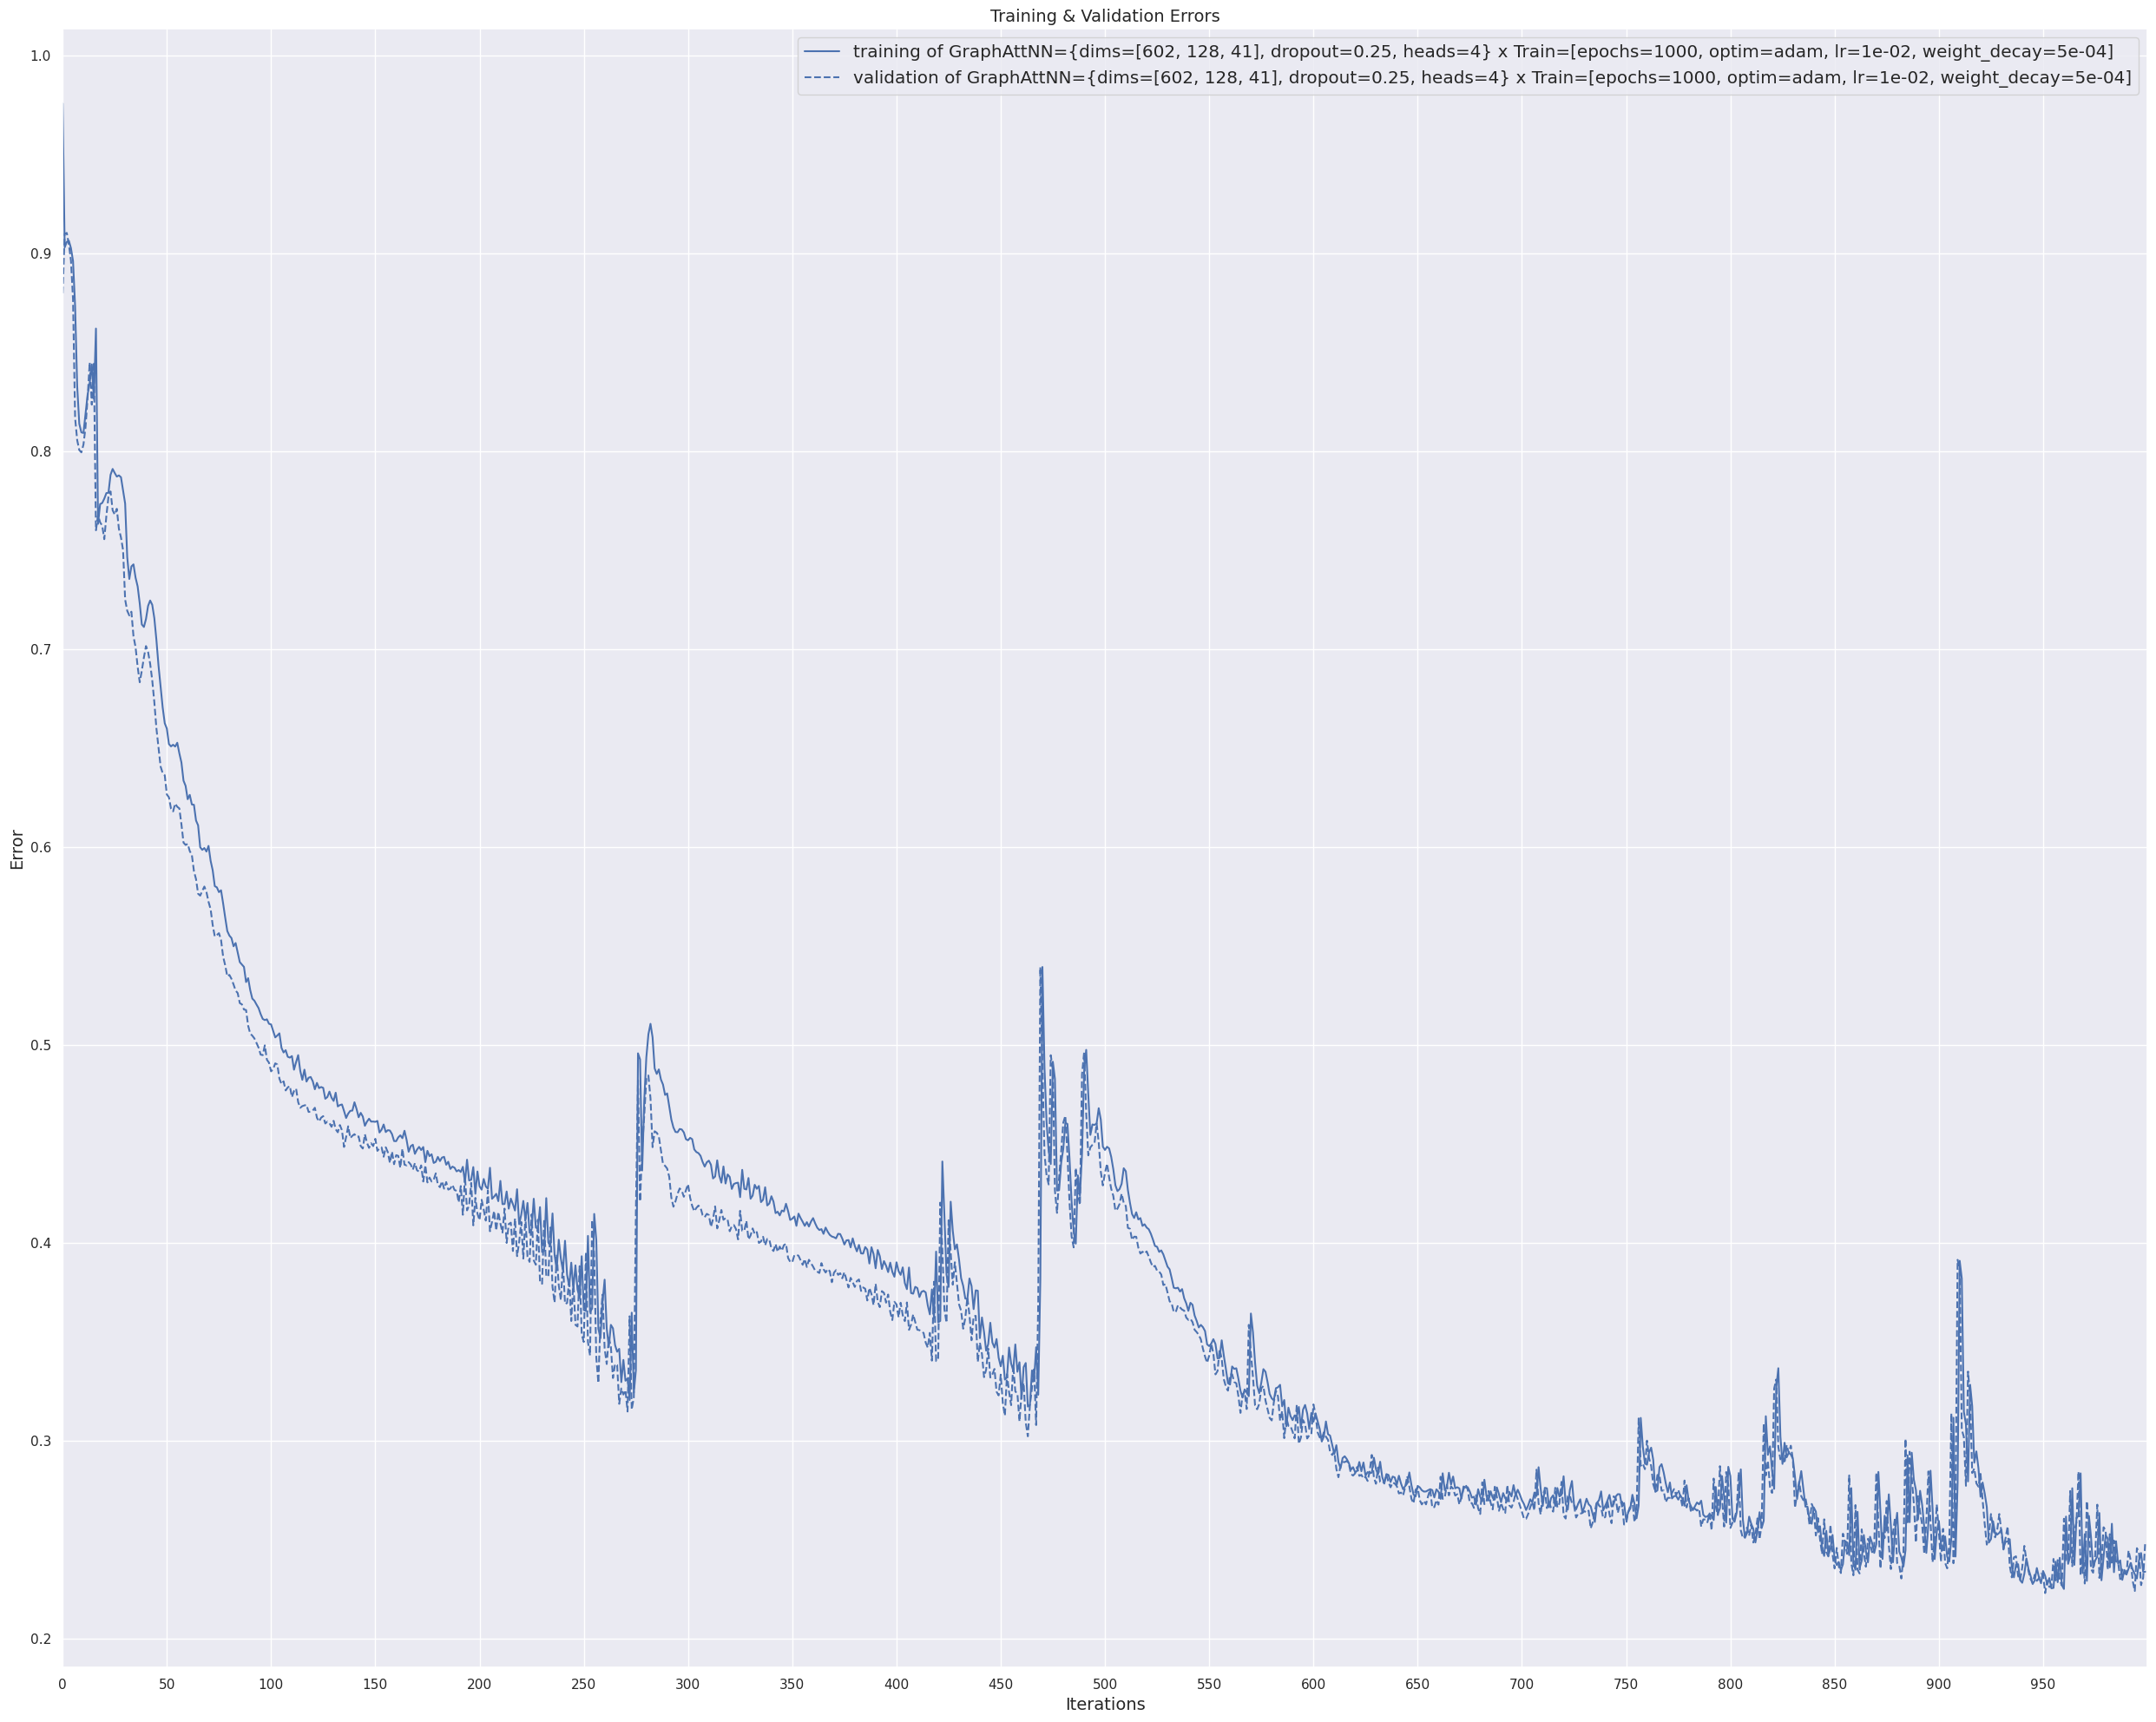

In [13]:
Utils.multi_line_plot(
    x_ticks_inc=50
    , fig_size=(25, 20)
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Errors"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_error for model_idp in trains[model_name][1]], [model_idp.val_error for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

In [9]:
print(f"best model is {top_model_names[0]} which achieves validation error of {min(trains[top_model_names[0]][1], key=lambda idp: idp.val_error).val_error:.4f}")

best model is GraphAttNN={dims=[602, 128, 41], dropout=0.25, heads=4} x Train=[epochs=1000, optim=adam, lr=1e-02, weight_decay=5e-04] which achieves validation error of 0.2232
